#### Case opti-4: Isobaric evaporation of ammonia in a large tank for long-term storage


In [1]:
# Ensure that python finds the submodules
import sys
sys.path.append("..") # Adds higher directory to python modules path.

# Scientific computing
import numpy as np

#import optimization class
from cryoevap.optimize import Opti_jax

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import JAX library
import jax
import jax.numpy as jnp

# Import time
import time

# Set JAX to use 64-bit precision
jax.config.update("jax_enable_x64", True)


#### Setup tank and cryogen properties

In [2]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

V_tank = 80000 # Tank volume / m^3

a   = 1
d_i = ((4 * V_tank)/(np.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.08  # W/m2/K
U_V = 0.08  # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.9

# Specify tank operating pressure
P = 100000 # Pa

# Set fixed bottom heat ingress
q_b_fixed = None

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)
large_tank.set_HeatTransProps(U_L, U_V, T_air, q_b_fixed = q_b_fixed, Q_roof = 0, eta_w = 0.90)

# # Initialise cryogen
cryogen = Cryogen(name = "ammonia")
cryogen.set_coolprops(P)

# # Set cryogen
large_tank.cryogen = cryogen

# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))
# comparison of heat flux
print("q_b used: ", q_b_fixed, " q_b free: ", U_L*(T_air - cryogen.T_sat))
print("Q_b used: ", large_tank.Q_b, " Q_b free: ", U_L*(T_air - cryogen.T_sat)*(np.pi*((d_i**2)/4)))

The initial evaporation rate of ammonia is 106.3 kg/h
q_b used:  None  q_b free:  4.686194202928102
Q_b used:  8027.4369080865  Q_b free:  8027.4369080865


Calculate initial evaporation rate and transient period

In [3]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + cryogen.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of ammonia is 106.3 kg/h
Transient period = 476513.154 s 
Simulation time: 133 h
BOR = 0.005 %


#### Simulation setup and execution

In [4]:
# Define vertical spacing
dz = 0.1

# Calculate number of nodes
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 720 hours
evap_time = 3600 * 720

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 3600

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
# large_tank.evaporate(evap_time)

In [5]:
opti = Opti_jax(large_tank)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


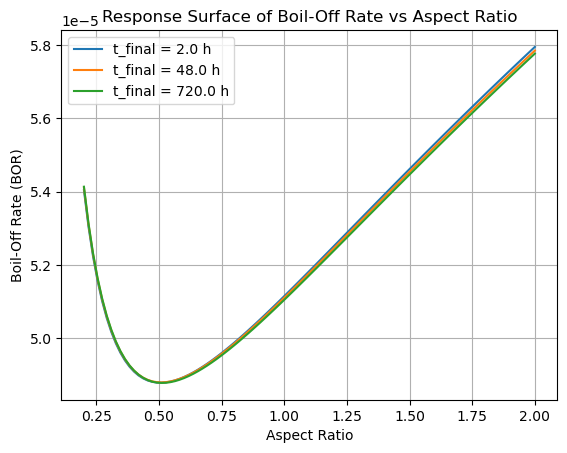

In [6]:
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 2*3600)
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 48*3600)
opti.plot_surface_response(jnp.linspace(0.2, 2, 100), 720*3600)

optimal Aspect Ratio: [0.94292929 0.72171717 0.60454545 0.53989899 0.50454545]
optimal BOR: [3.56786940e-04 1.23915452e-04 7.83749870e-05 5.82468830e-05
 4.64161988e-05]


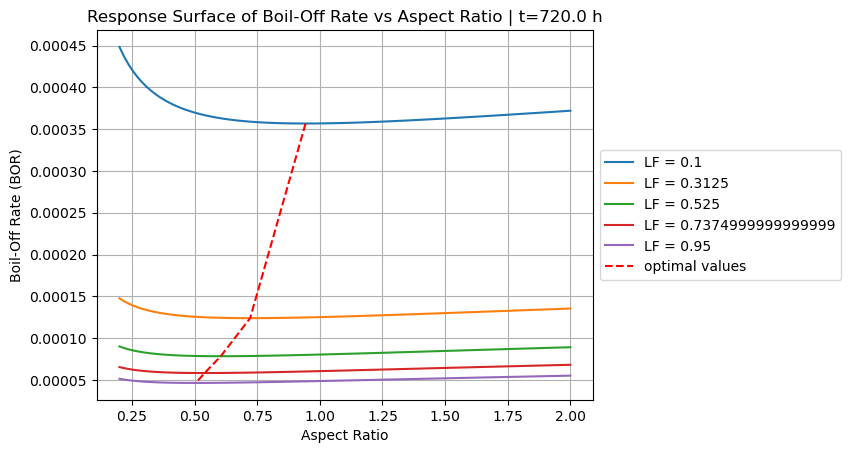

In [8]:
opti.plot_surface_response_liquid_filling(jnp.linspace(0.2, 2, 100), jnp.linspace(0.1, 0.95, 5),720*3600)

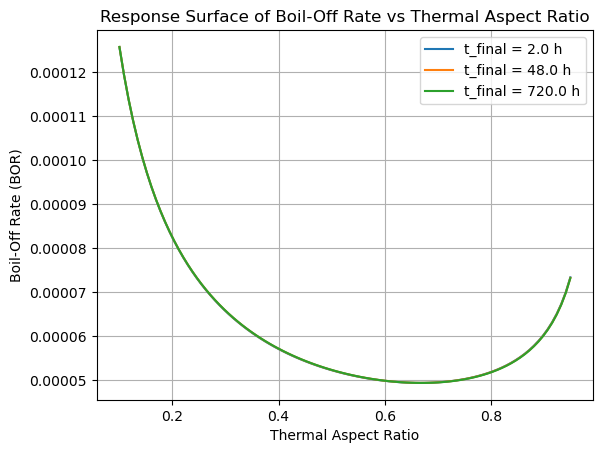

In [9]:
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.95, 100), 2*3600)
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.95, 100), 48*3600)
opti.plot_thermal_surface_response(jnp.linspace(0.1, 0.95, 100), 720*3600)

optimal Thermal Aspect Ratio: [0.72895168 0.70300755 0.68594504 0.67518883 0.66931022]
optimal BOR: [3.61433597e-04 1.30191287e-04 8.28467636e-05 6.17724680e-05
 4.94181953e-05]


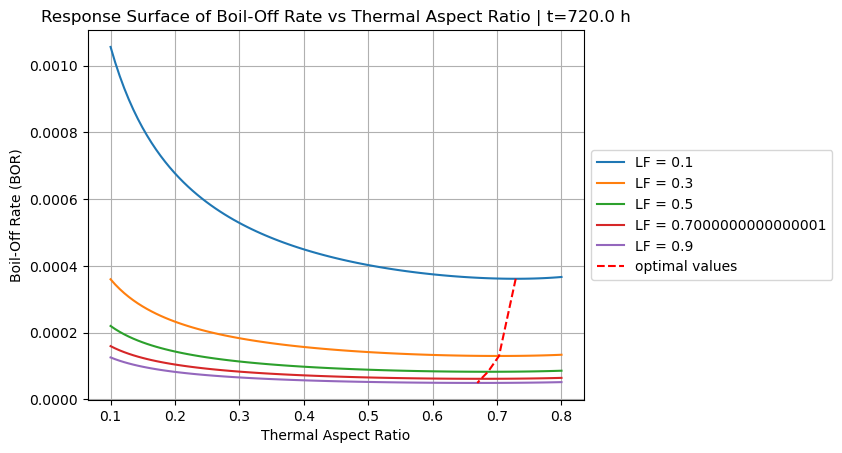

In [6]:
opti.plot_surface_response_thermal_liquid_filling(jnp.linspace(0.1, 0.8, 100), jnp.linspace(0.1, 0.9, 5),720*3600)

/home/milcaito/anaconda3/lib/python3.9/site-packages/cryoevap/optimize/opti_jax.py:517: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))


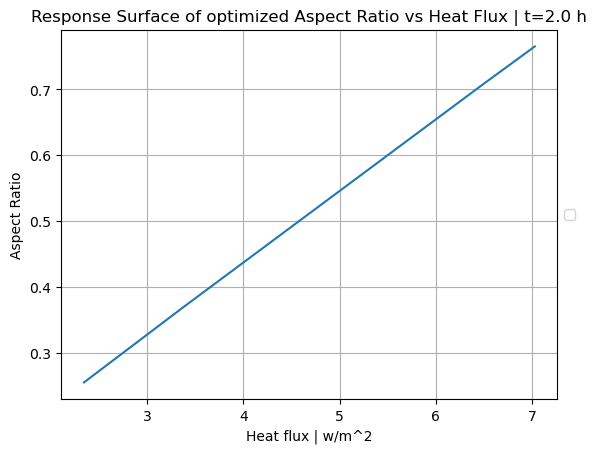

In [8]:
opti.plot_surface_response_bottom_heat(jnp.linspace(U_L*(T_air - cryogen.T_sat)*0.5, U_L*(T_air - cryogen.T_sat)*1.5, 10), 2*3600)

In [9]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=2*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.511111, BOR: 4.878616e-05
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 0.505255
Minimum BOR: 4.878543e-05
Tiempo de ejecución: 2.78 segundos


In [10]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=48*3600, coarse_samples=100, fine_samples=1000,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.511111, BOR: 4.879437e-05
Phase 2: Fine grid search with 1000 samples...
Refined optimal aspect ratio: 0.508458
Minimum BOR: 4.879423e-05
Tiempo de ejecución: 9.86 segundos


In [11]:
start_time = time.time()
opti.optimize_grid_with_refinement(verbose=True, t_final=720*3600, coarse_samples=100, fine_samples=100,
                                   aspect_ratio_min=0.2, aspect_ratio_max=3, refinement_window=0.1)
end_time = time.time()
print(f"Tiempo de ejecución: {end_time - start_time:.2f} segundos")

Phase 1: Coarse grid search with 100 samples...
Coarse search optimal: 0.511111, BOR: 4.877996e-05
Phase 2: Fine grid search with 100 samples...
Refined optimal aspect ratio: 0.511616
Minimum BOR: 4.877995e-05
Tiempo de ejecución: 25.56 segundos


In [12]:
# optimal_aspect_ratio = opti.optimize(max_iter = 500, t_final = 2 * 3600, lr = 1e-2, x0 = 0, lr_2 = 1e-3, iter_decay_lr=75)
# opti.plot_loss_history()

In [13]:
opti.optimal_aspect_ratio

Array(0.51161616, dtype=float64)

#### Visualisation of results

#### Vapour temperature

In [14]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

TypeError: The solution object tank.sol does not exist.
Run tank.evaporate(t) to generate a solution
and thereafter run tank.plot_tv() again

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

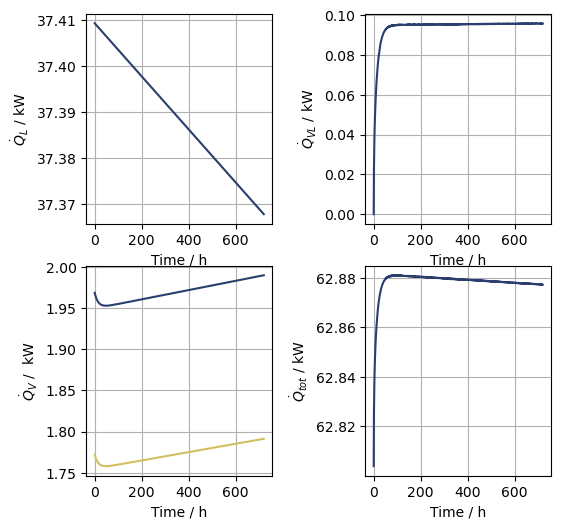

In [ ]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

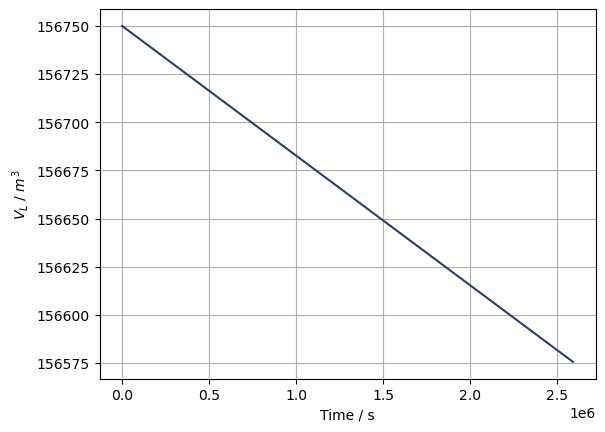

In [ ]:
large_tank.plot_V_L()

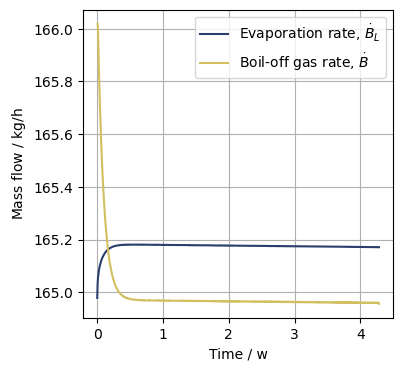

In [ ]:
large_tank.plot_BOG(unit='kg/h', t_unit='w')

Optional: CSV data export

If evaporation data is intended to be post-processed in another software, it can be exported readily with the help of the Pandas package.

In [ ]:
# Import pandas 
import pandas as pd

In [ ]:
# Create dataframe from dictionary
df_evap = pd.DataFrame.from_dict(large_tank.data)

# Save file to the current working directory
df_evap.to_csv('methane_165000m3.csv')

# Show the first five columns of the dataframe in console
df_evap.head()

In [ ]:
# BOR = (1 - large_tank.data['V_L'][-1]/large_tank.data['V_L'][0])* (86400/large_tank.data['Time'][-1])
BOR = large_tank.BOR()
print("BOR = %.3e %%" % (100 * BOR))

In [ ]:
large_tank.BOR()

In [ ]:
large_tank.data['Time'][-1]

In [ ]:
large_tank.plot_tv_BOG(t_unit='w')

#### References



F. Huerta, V. Vesovic, A realistic vapour phase heat transfer model for the weathering of LNG stored in large tanks, Energy, 174 (2019) 280-291.